# 01_Understanding Data

# 1. Data overview 
## 1.1 Objective
The purpose of this notebook is to understand the hotel booking dataset before performing data cleaning and preprocessing.

This step helps identify:
- Dataset structure
- Data types
- Missing values
- Outliers
- Distribution patterns
- Potential data quality issues

## 1.2 Import Libraries
- pandas: used for handling tabular data
- numpy: used for numerical operations
- matplotlib: used for data visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1.3 Load and Explore Dataset ##

This step helps identify potential data quality issues before deeper analysis.
- The dataset contains hotel booking information.
- Each row represents one hotel reservation.
- The dataset includes both numerical and categorical variables.
- The target variable for classification is `is_canceled`.

In [2]:
df = pd.read_csv("../Data/hotel_bookings.csv")


In [3]:
# Preview first rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [41]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

summary = pd.DataFrame({
    'Feature Type': ['Numerical', 'Categorical'],
    'Count': [len(numerical_cols), len(categorical_cols)]
})

summary

/var/folders/wm/syfg483s7cxcwfsh1p497_yr0000gn/T/ipykernel_44909/2996468261.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,Feature Type,Count
0,Numerical,20
1,Categorical,12


__Data Information__

- The dataset contains both numerical and categorical features.
- Some columns contain missing values such as `children`, `country`, and `agent`.
- Most categorical variables are stored as object type.

In [5]:
df.shape

(119390, 32)

The dataset contains 119,390 rows and 32 columns.

In [23]:
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 31994


The dataset contains 31994 duplicate rows 

In [24]:
# Statistical summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


__Statistical Summary__

- Some numerical variables contain extreme values.
- `lead_time` has a very high maximum value.
- `adr` may contain outliers due to unusually high room prices.

## 1.4 Initial Observations

From the initial exploration of the dataset:
- The dataset contains both numerical and categorical variables.
- Some variables contain missing values that may require cleaning later.
- Several numerical variables appear to contain skewed distributions and potential outliers.
- The target variable of this project is `is_canceled`, which indicates whether a booking was canceled or not.


Further analysis will be conducted in the following sections to better understand feature distributions and their relationships with booking cancellation behavior.

In [25]:
#Check missing value 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# 2. Data Classification

## 2.1 Numerical Features

- Numerical features contain quantitative values that can be measured or counted.

- These variables are important for statistical analysis, visualization, and predictive modeling.

In [26]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Number of Numerical Features:", len(numerical_features))
print(numerical_features.tolist())

Number of Numerical Features: 20
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


## 2.2 Categorical Features ##

- Categorical features contain qualitative information represented by categories or labels.

- These variables help describe booking characteristics, customer types, hotel types, and other non-numeric information.

In [27]:
categorical_features = df.select_dtypes(
    include=['object']
).columns

print("Number of Categorical Features:", len(categorical_features))
print(categorical_features.tolist())

Number of Categorical Features: 12
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


/var/folders/wm/syfg483s7cxcwfsh1p497_yr0000gn/T/ipykernel_44909/48299027.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


## 2.3 Target Variable ##

The target variable of this project is `is_canceled`.

This variable indicates whether a hotel booking was canceled:
- `0` = Not Canceled
- `1` = Canceled

The objective of the predictive model is to classify bookings based on their cancellation probability.

In [28]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [29]:
df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

# 3. Constant Features and Missing Values #
## 3.1. Checking Constant Features ##

In [30]:
# Select columns with only one unique value
single_value_cols = df.columns[df.nunique() == 1]

print(f"Number of columns with a single unique value: {len(single_value_cols)}")
print(f"Columns with a single unique value: {list(single_value_cols)}")

Number of columns with a single unique value: 0
Columns with a single unique value: []


- The dataset does not contain any constant features.
This means every variable has at least more than one unique value and may provide useful information for analysis or predictive modeling.

- Constant features are usually removed because they do not contribute to explaining patterns or differences in the data. In this dataset, no such columns were detected.

## 3.2. Checking missing values 

In [31]:
# Columns with missing values
missing_cols = df.columns[df.isnull().any()]

# Count missing values
missing_counts = df[missing_cols].isnull().sum()

# Missing percentage
missing_percent = (df[missing_cols].isnull().mean() * 100)

# Group missing levels
high_missing = missing_percent[missing_percent > 50].sort_values(ascending=False)
medium_missing = missing_percent[
    (missing_percent <= 50) & (missing_percent > 10)
].sort_values(ascending=False)

low_missing = missing_percent[missing_percent <= 10].sort_values(ascending=False)

print("Number of columns with missing values:", len(missing_cols))
print("High missing (>50%):", high_missing.shape[0])
print("Medium missing (10%-50%):", medium_missing.shape[0])
print("Low missing (<=10%):", low_missing.shape[0])

Number of columns with missing values: 4
High missing (>50%): 1
Medium missing (10%-50%): 1
Low missing (<=10%): 2


In [32]:
#Display missing value groups 
def print_missing(title, series):
    print(f"\n{title} ({len(series)} columns)")
    print("-" * 60)

    for col in series.index:
        print(f"{col:<25} {missing_percent[col]:>8.2f}%")

print_missing("High Missing (>50%)", high_missing)
print_missing("Medium Missing (10%-50%)", medium_missing)
print_missing("Low Missing (<=10%)", low_missing)


High Missing (>50%) (1 columns)
------------------------------------------------------------
company                      94.31%

Medium Missing (10%-50%) (1 columns)
------------------------------------------------------------
agent                        13.69%

Low Missing (<=10%) (2 columns)
------------------------------------------------------------
country                       0.41%
children                      0.00%


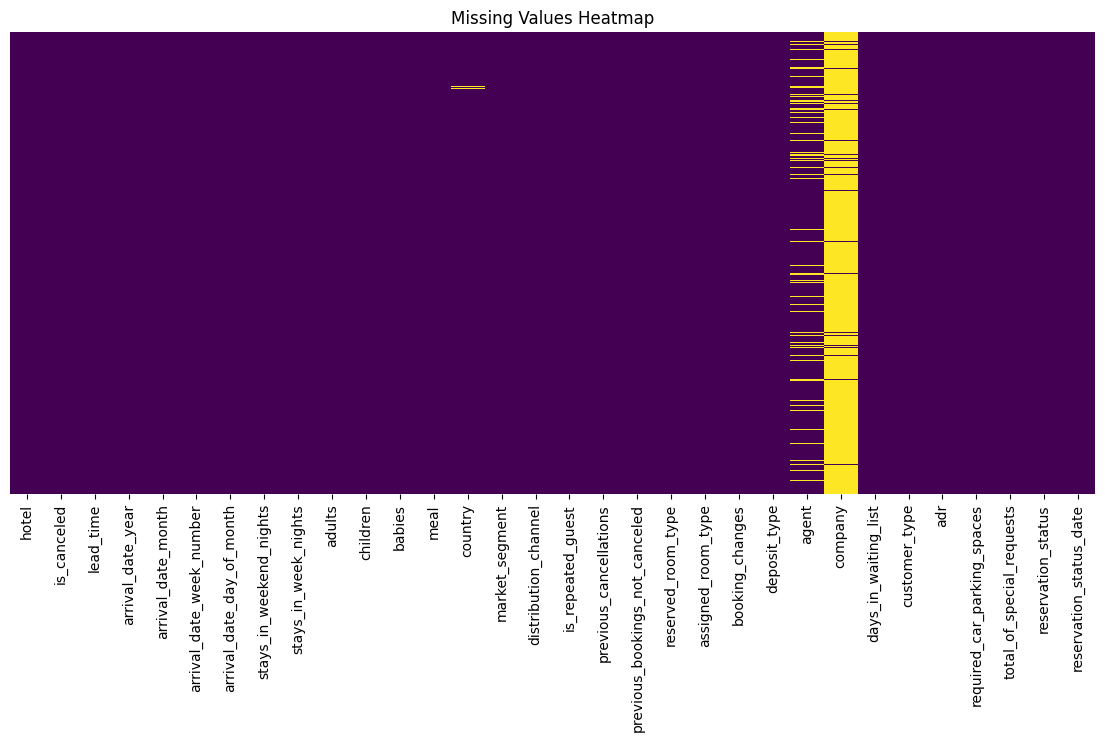

In [33]:
#Missing value heatmap
import seaborn as sns
plt.figure(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

__1. High Missing Group (>50%)__

Features such as `company` and `agent` contain a very large number of missing values.  
This mainly happens because many customers booked hotels directly without companies or travel agencies.

These variables may require:
- imputation,
- treating missing values as a separate category,
- or removal if necessary.


__2. Medium Missing Group (10%-50%)__

Features like `children` and `country` contain a moderate amount of missing data.

The missing values may result from incomplete customer information during the booking process.  
These variables can still be useful after preprocessing.




__3. Low Missing Group (<=10%)__

Most variables belong to this group and contain only a small percentage of missing values.

These missing values are generally manageable and can be handled using standard preprocessing methods.

# 4. Feature Analysis 
## 4.1 Target Variable Analysis

- The dataset contains both canceled and non-canceled bookings.
- The classes are relatively balanced for classification analysis.

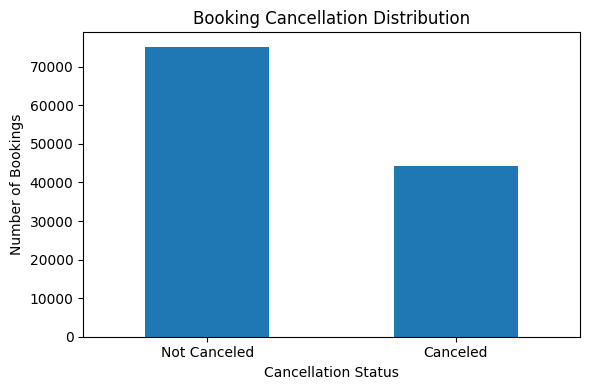

In [34]:
#Booking cancellation distribution 
cancel_counts = df['is_canceled'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

cancel_counts.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Booking Cancellation Distribution')
ax.set_xlabel('Cancellation Status')
ax.set_ylabel('Number of Bookings')

ax.set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

plt.tight_layout()
plt.show()

## Booking Cancellation Distribution

The dataset contains both canceled and non-canceled bookings.

Non-canceled bookings appear more frequently than canceled bookings, although the cancellation rate is still significant.

This indicates that booking cancellation prediction is a meaningful business problem for hotel management.

In [42]:
cancel_rate = df['is_canceled'].mean() * 100

print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancellation Rate: 37.04%


The dataset is moderately balanced for classification analysis.

## 4.2 Numerical Variable Analysis
___4.2.1 Lead Time Distribution___

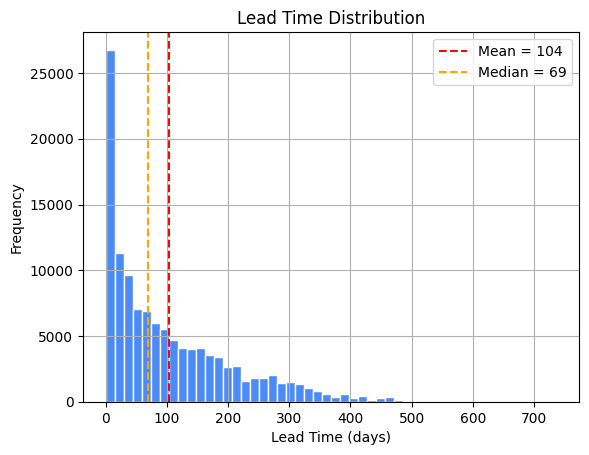

In [35]:
df['lead_time'].hist(
    bins=50,
    color='#4C8BF5',
    edgecolor='white'
)

plt.axvline(
    df['lead_time'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['lead_time'].mean():.0f}"
)

plt.axvline(
    df['lead_time'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['lead_time'].median():.0f}"
)

plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')

plt.legend()

plt.show()

### Lead Time Distribution

- The lead time variable is positively skewed.

- Most bookings were made within a relatively short period before arrival, while some bookings have extremely long lead times.

- The mean is higher than the median, indicating the presence of high-value outliers.

___4.2.2 Lead Time vs Cancellation___

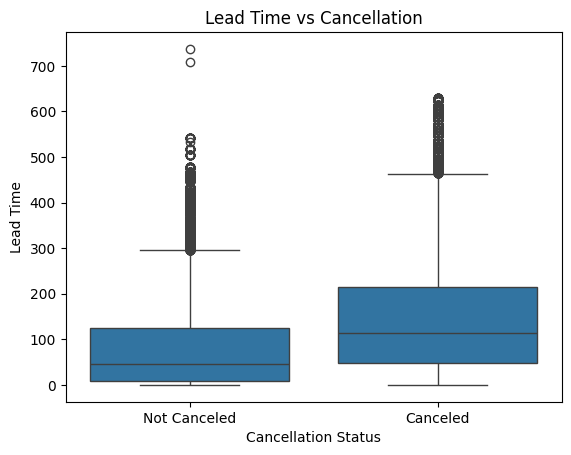

In [36]:
sns.boxplot(
   x='is_canceled',
   y='lead_time',
   data=df
)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time')

plt.xticks([0,1], ['Not Canceled', 'Canceled'])

plt.show()

### Lead Time vs Cancellation

Bookings with longer lead times tend to have higher cancellation probability.

Customers who book far in advance may be more likely to change their travel plans later.

___4.2.3 Outlier Detection (ADR)___

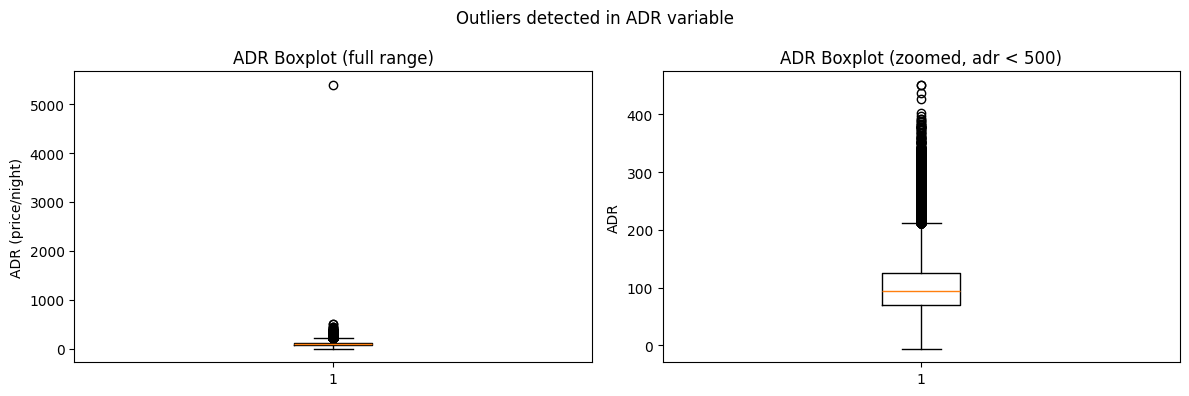

In [37]:
# Outlier detection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot full range
axes[0].boxplot(df['adr'])
axes[0].set_title('ADR Boxplot (full range)')
axes[0].set_ylabel('ADR (price/night)')

# Zoomed version
axes[1].boxplot(df[df['adr'] < 500]['adr'])
axes[1].set_title('ADR Boxplot (zoomed, adr < 500)')
axes[1].set_ylabel('ADR')

plt.suptitle('Outliers detected in ADR variable')

plt.tight_layout()
plt.show()

### Outlier Detection

- The ADR variable contains several extreme outliers and one negative value.

- A second zoomed boxplot was used to better visualize the main distribution of ADR values below 500.

- These outliers may affect model performance and should be considered during the data cleaning phase.

___4.2.4 Correlation Heatmap___

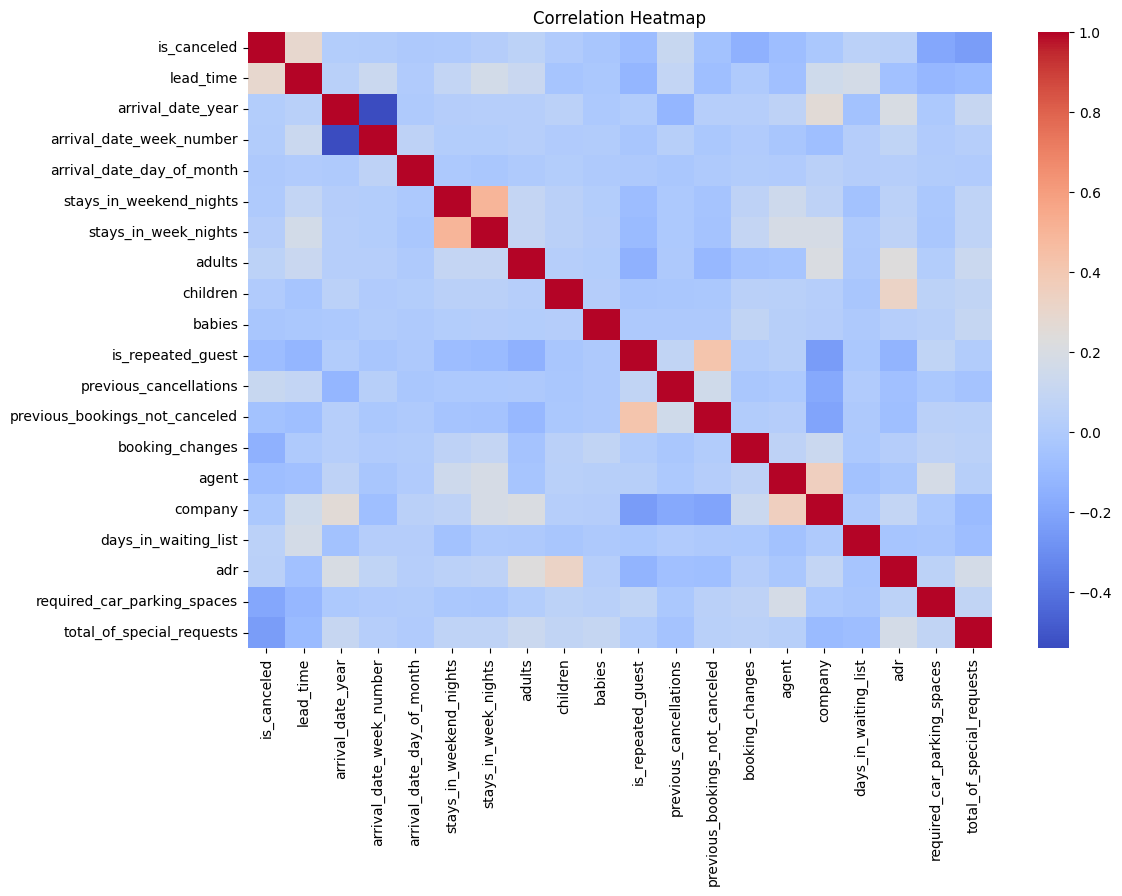

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numerical_cols].corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## Correlation Analysis

Most numerical variables show weak correlations with one another, indicating low multicollinearity within the dataset.

However, several moderate relationships can still be observed:
- `stays_in_week_nights` and `stays_in_weekend_nights`
- `is_repeated_guest` and `previous_bookings_not_canceled`
- `adr` and `children`

Overall, the dataset appears suitable for further machine learning analysis without severe multicollinearity concerns.

## 4.3 Categorical Variable Analysis 
___4.3.1 Basic Categorical Distributions___

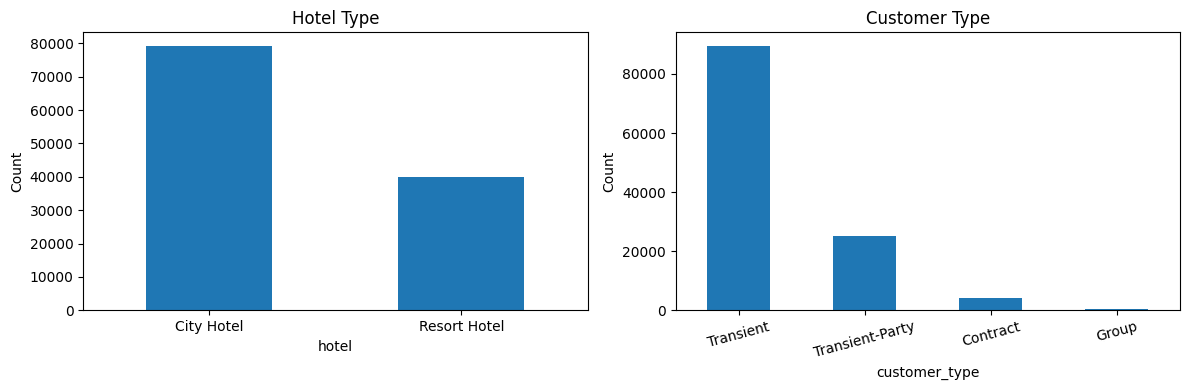

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hotel type distribution
df['hotel'].value_counts().plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Hotel Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Customer type distribution
df['customer_type'].value_counts().plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('Customer Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Categorical Variable Analysis

The dataset contains different hotel and customer types.

- City Hotel bookings appear more frequently than Resort Hotel bookings.
- The majority of customers belong to the “Transient” category.

The categorical variables are not evenly distributed and may influence booking cancellation behavior.

___4.3.2. Deposit Type vs Cancellation Rate___

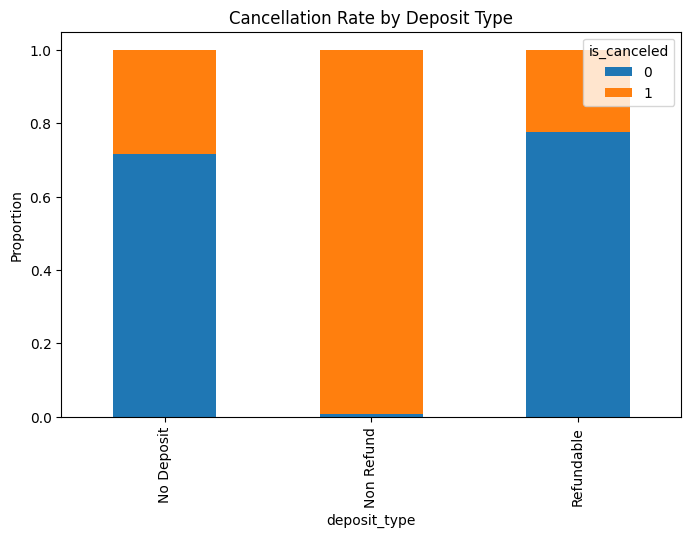

In [ ]:
cancel_by_deposit = pd.crosstab(
   df['deposit_type'],
   df['is_canceled'],
   normalize='index'
)

cancel_by_deposit.plot(
   kind='bar',
   stacked=True,
   figsize=(8,5)
)

plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Proportion')

plt.show()

### Deposit Type vs Cancellation Rate

- Customers with non-refundable deposits are significantly less likely to cancel bookings.

- Deposit policies appear to strongly influence customer cancellation behavior.

___4.3.3 Hotel Type vs Cancellation Rate___

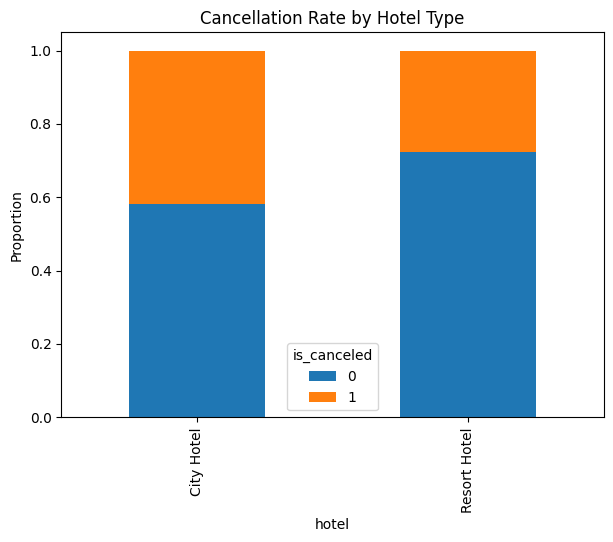

In [ ]:
hotel_cancel = pd.crosstab(
   df['hotel'],
   df['is_canceled'],
   normalize='index'
)

hotel_cancel.plot(
   kind='bar',
   stacked=True,
   figsize=(7,5)
)

plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Proportion')

plt.show()

### Hotel Type vs Cancellation Rate

- City Hotel bookings show a higher cancellation rate compared to Resort Hotel bookings.

- Different hotel types may attract different customer behaviors and booking patterns.

# Final conclusion 
The dataset contains hotel booking information with both numerical and categorical variables.

Several data quality issues were identified:
- Missing values in columns such as `company`, `agent`, and `country`
- Potential outliers in `adr`
- Skewed distributions in variables like `lead_time`

These issues will need to be addressed during the data cleaning and preprocessing stage before building machine learning models.
